# Spectral Data Reduction Tutorial

This notebook demonstrates the Stage 2 spectral extraction pipeline:

1. **Fiber identification & tracing** — detect fibers and model their curvature
2. **Profile modeling** — measure the cross-dispersion PSF from a master flat
3. **Spectral extraction** — convert 2-D images into 1-D row-stacked spectra (`FiberFrame`)

We use a synthetic image for reproducibility.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from amasedrp.reduction import (
    identify_and_trace_fibers,
    extract_spectra,
    run_quick_reduction,
    run_reduction,
)
from amasedrp.reduction.methods.profile_modeling import build_fiber_profile

## 1. Generate Synthetic Data

Create a synthetic fiber-flat and a science frame with straight Gaussian fibers.

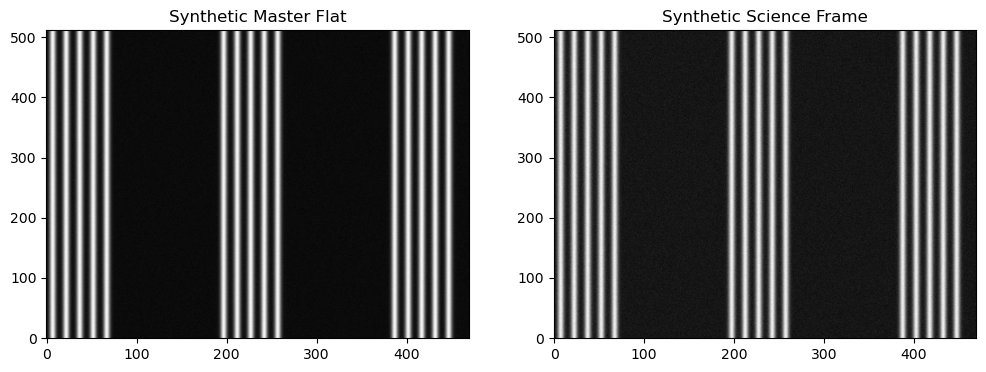

In [2]:
def synthetic_fiber_flat(
    n_rows=512,
    n_blocks=3,
    n_fibers_per_block=5,
    fiber_sigma=2.5,
    fiber_spacing=15,
    block_gap=100,
):
    fiber_profile_width = int(6 * fiber_sigma)
    block_width = n_fibers_per_block * fiber_spacing + fiber_profile_width
    n_cols = n_blocks * block_width + (n_blocks - 1) * block_gap
    image = np.zeros((n_rows, n_cols), dtype=np.float64)
    x = np.arange(n_cols)
    col_offset = fiber_profile_width // 2
    for b in range(n_blocks):
        for f in range(n_fibers_per_block):
            center = col_offset + f * fiber_spacing
            profile = np.exp(-0.5 * ((x - center) / fiber_sigma) ** 2)
            image += profile[np.newaxis, :]
        col_offset += block_width + block_gap
    return image + np.random.default_rng(42).normal(0, 0.01, (n_rows, n_cols))

flat = synthetic_fiber_flat()
science = flat + np.random.default_rng(123).normal(0, 0.02, flat.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(flat, aspect='auto', origin='lower', cmap='gray')
axes[0].set_title('Synthetic Master Flat')
axes[1].imshow(science, aspect='auto', origin='lower', cmap='gray')
axes[1].set_title('Synthetic Science Frame')
plt.show()

## 2. Identify and Trace Fibers

One-shot detection and polynomial tracing via `identify_and_trace_fibers`.

In [3]:
fibermap, tracemask = identify_and_trace_fibers(
    image=flat,
    n_blocks_expected=3,
    n_fibers_per_block_expected=5,
)
print(f"Detected {fibermap.n_fibers} fibers")

Detected 15 fibers


## 3. Build Fiber Profile

Extract the normalized cross-dispersion profile from the master flat.
This profile is required for optimal extraction.

In [4]:
fiber_profile = build_fiber_profile(
    flat_image=flat,
    tracemask=tracemask,
    fibermap=fibermap,
    half_width=5,
)
print(f"Profile shape: {fiber_profile.profile.shape}")
print(f"Offsets: {fiber_profile.x_offsets}")

Profile shape: (15, 512, 11)
Offsets: [-5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.]


## 4. Boxcar Extraction

Simple aperture-sum extraction — fast and useful for quick-look QA.

Boxcar FiberFrame: (15, 512)


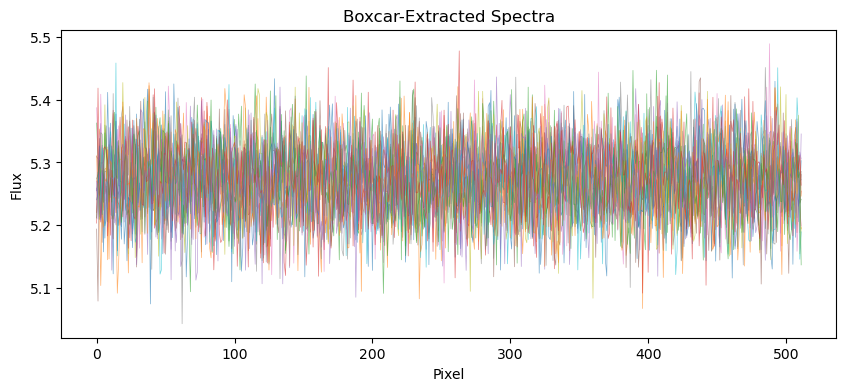

In [5]:
frame_boxcar = extract_spectra(
    image=science,
    tracemask=tracemask,
    fibermap=fibermap,
    method="boxcar",
    aperture_radius=3,
)
print(f"Boxcar FiberFrame: {frame_boxcar.shape}")

fig, ax = plt.subplots(figsize=(10, 4))
for i in range(frame_boxcar.n_fibers):
    ax.plot(frame_boxcar.wave, frame_boxcar.flux[i], alpha=0.6, lw=0.5)
ax.set_xlabel('Pixel')
ax.set_ylabel('Flux')
ax.set_title('Boxcar-Extracted Spectra')
plt.show()

## 5. Quick-Look Pipeline

`run_quick_reduction` wraps identification + boxcar extraction in one call.

In [6]:
quick_frame = run_quick_reduction(
    image=science,
    flat_image=flat,
    n_blocks_expected=3,
    n_fibers_per_block_expected=5,
)
print(f"Quick-look frame: {quick_frame.shape}")

Quick-look frame: (15, 512)


## 6. Full Reduction Pipeline

`run_reduction` builds the fiber profile and attempts optimal extraction.

> **Note:** Optimal extraction is currently a placeholder. Calling `method="optimal"` will raise `NotImplementedError`. Use `method="boxcar"` for now.

In [7]:
full_frame = run_reduction(
    image=science,
    flat_image=flat,
    n_blocks_expected=3,
    n_fibers_per_block_expected=5,
    method="boxcar",
)
print(f"Full reduction frame: {full_frame.shape}")
print(f"Metadata: {full_frame.meta}")

Full reduction frame: (15, 512)
Metadata: {'METHOD': 'boxcar', 'APERTURE': 3}


## 7. Save and Load `FiberFrame`

`FiberFrame` supports FITS I/O for checkpointing pipeline steps.

In [8]:
frame_boxcar.to_fits("demo_fiberframe.fits", overwrite=True)
restored = frame_boxcar.__class__.from_fits("demo_fiberframe.fits")
print(f"Restored frame shape: {restored.shape}")
np.testing.assert_array_equal(restored.flux, frame_boxcar.flux)

Restored frame shape: (15, 512)


## Summary

The reduction stage converts 2-D images → 1-D spectra via:

- `identify_and_trace_fibers` → `FiberMap` + `TraceMask`
- `build_fiber_profile` → `FiberProfile`
- `extract_spectra(method="boxcar")` → `FiberFrame`
- `run_quick_reduction` / `run_reduction` → end-to-end orchestrators

Next step: feed the `FiberFrame` into `calibration/` for wavelength calibration, sky subtraction, and flux calibration.